In [1]:
from utils import *

In [2]:
EJ=8.9
EC=2.5
EL=0.5
g_strength = 0.3

E_osc = 3

qubit_level = 4
osc_level = 10

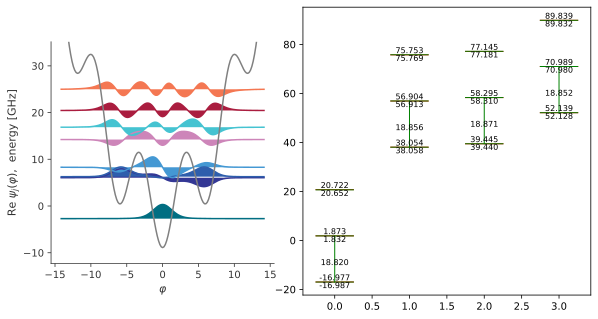

In [3]:
qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=30,truncated_dim=qubit_level)
osc = scqubits.Oscillator(E_osc=E_osc,truncated_dim=osc_level)
hilbertspace = scqubits.HilbertSpace([qbt, osc])
hilbertspace.add_interaction(g_strength=g_strength,op1=qbt.n_operator,op2=osc.creation_operator,add_hc=True)
hilbertspace.generate_lookup()
product_to_dressed = generate_single_mapping(hilbertspace.hamiltonian())
# plot_specturum(qbt, osc, hilbertspace)

In [4]:
# sweep_resonator_frequency_for_ge_gf_gh_detunning(EJ=8.9,
#                                         EC=2.5,
#                                         EL=0.5,
#                                         flux = 0,
#                                         g_strength = 0.3)

10.0%. Run time:   0.36s. Est. time left: 00:00:00:03
20.0%. Run time:   0.78s. Est. time left: 00:00:00:03
30.0%. Run time:   1.16s. Est. time left: 00:00:00:02
40.0%. Run time:   1.54s. Est. time left: 00:00:00:02
50.0%. Run time:   1.93s. Est. time left: 00:00:00:01
60.0%. Run time:   2.33s. Est. time left: 00:00:00:01
70.0%. Run time:   2.72s. Est. time left: 00:00:00:01
80.0%. Run time:   3.12s. Est. time left: 00:00:00:00
90.0%. Run time:   3.52s. Est. time left: 00:00:00:00
Total run time:   3.90s
10.0%. Run time:   0.26s. Est. time left: 00:00:00:02
20.0%. Run time:   0.58s. Est. time left: 00:00:00:02
30.0%. Run time:   0.85s. Est. time left: 00:00:00:01
40.0%. Run time:   1.15s. Est. time left: 00:00:00:01
50.0%. Run time:   1.75s. Est. time left: 00:00:00:01
60.0%. Run time:   2.07s. Est. time left: 00:00:00:01
70.0%. Run time:   2.39s. Est. time left: 00:00:00:01
80.0%. Run time:   2.76s. Est. time left: 00:00:00:00
90.0%. Run time:   3.10s. Est. time left: 00:00:00:00
Tota

 /home/jiakai/.local/lib/python3.10/site-packages/jax/_src/array.py: 363

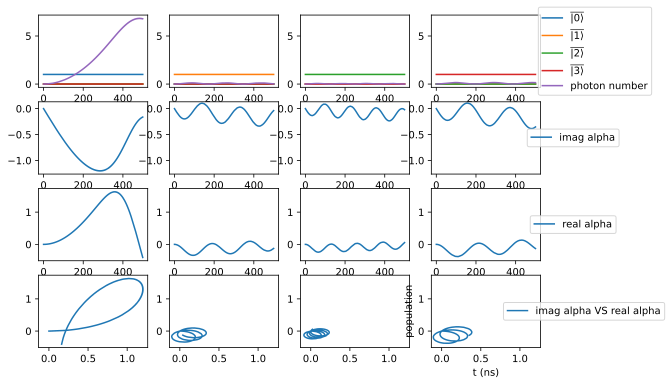

In [23]:
a = hilbertspace.op_in_dressed_eigenbasis(op=osc.annihilation_operator)
a = qutip.Qobj(a[:, :])
 
(evals,) = hilbertspace["evals"]
diag_dressed_hamiltonian = (
        2 * np.pi * qutip.Qobj(np.diag(evals),
        dims=[hilbertspace.subsystem_dims] * 2)
)
diag_dressed_hamiltonian = qutip.Qobj(diag_dressed_hamiltonian[:, :])

leakage_dressed_state_osc_0 = product_to_dressed[(0,0)]
leakage_dressed_state_osc_1 = product_to_dressed[(0,1)]
w_d = transition_frequency(hilbertspace,leakage_dressed_state_osc_0,leakage_dressed_state_osc_1 )
# w_d = transition_frequency(hilbertspace,product_to_dressed[(0,0)], product_to_dressed[(0,1)])/2+transition_frequency(hilbertspace,product_to_dressed[(3,0)], product_to_dressed[(3,1)])/2


tot_time = 500
tlist = np.linspace(0, tot_time, tot_time*20)

# matrix_element_driven = abs((a+a.dag()).data.toarray()[leakage_dressed_state_osc_0][leakage_dressed_state_osc_1])
# A_square = 1/tot_time
# A_square = A_square/matrix_element_driven
A_square = 0.002

def square_cos(t,*args):
    cos = np.cos(w_d * 2*np.pi * t)
    return  2*np.pi *A_square * cos

H_with_drive = [
    diag_dressed_hamiltonian,
    [a+a.dag(), square_cos]]

kappa = 0.01
decay_term = np.sqrt(kappa)*a


results = []
for i in range(4):
    temp = solve_with_mesolve(
        H = H_with_drive,
        state0=  qutip.basis(hilbertspace.dimension, product_to_dressed[(i,0)]),
        tlist = tlist,
        options=qutip.Options(store_states=True,nsteps=1000,num_cpus = 12),
    )
    results.append(temp)


plot_population(results,qubit_level,osc_level,product_to_dressed,a,w_d,tlist,fourier=True)